# Phase 8: The Delta-Network Full Waveform Inversion ($\Delta V$)
**Target:** Marmousi2 Central Graben (True 2D Structural Geology)
**Architecture:** Anisotropic Latent-Fourier DDR-PINN (Delta Formulation)

This notebook executes the definitive, physically bounded Full Waveform Inversion pipeline. It bypasses the "Catastrophic Forgetting" and "Local Minimum" traps of standard PINNs by separating the inversion into two distinct physical stages:
1. **Macro-Model Embedding:** Utilizing Transfer Learning to lock a tomographic Migration Velocity Model (MVM) into the network's latent space.
2. **Delta-FWI:** Forcing the neural network to act strictly as a perturbation engine ($\Delta V$), utilizing high-frequency wavefield residuals (5Hz $\rightarrow$ 25Hz) to sculpt sharp geometrical faults into the frozen prior.

In [ ]:
# ==========================================
# CELL-1. HARDWARE & UNCOMPROMISING DATA INGESTION
# ==========================================
import os
import gc
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage
import segyio
import deepwave
import matplotlib.patches as patches

# Initialize Hardware
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"HPC Node Active: {device}\n")

In [2]:
# ==========================================
# CELL-2. DATA INGESTION & THE MICROSCOPE STRATEGY
# ==========================================
# Raw SEG-Y Ingestion
segy_path = os.path.join("vp_marmousi-ii", "vp_marmousi-ii.segy")

print("Extracting Raw SEG-Y & Applying Physical Corrections...")
with segyio.open(segy_path, ignore_geometry=True, strict=False) as segy_file:
    marmousi_raw = np.array(segy_file.trace.raw[:], dtype=np.float32)

# Correct AGL km/s to m/s
marmousi_vp_ms = marmousi_raw * 1000.0

# The Microscope Strategy: Extract 700x700m Graben & Decimate to 10m grid
x_start, z_start = 7200, 800
step = 8
patch_vp = marmousi_vp_ms[x_start:x_start+560:step, z_start:z_start+560:step]

nx, nz = patch_vp.shape
dx, dz = 10.0, 10.0
print(f"Extraction Complete. Computational Grid: {nx} x {nz} (dx = 10m)")

Extracting Raw SEG-Y & Applying Physical Corrections...


NameError: name 'segyio' is not defined

In [ ]:
# ==========================================
# CELL-3. ARCHITECTURAL DEFINITION (FOURIER DELTA PINN)
# ==========================================
class FourierDeltaPINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.B = nn.Parameter(torch.randn(2, 64) * 10.0, requires_grad=False)
        self.net = nn.Sequential(
            nn.Linear(128, 256), nn.Mish(),
            nn.Linear(256, 256), nn.Mish(),
            nn.Linear(256, 256), nn.Mish(),
            nn.Linear(256, 256), nn.Mish(),
            nn.Linear(256, 1)
        )
        
    def forward(self, x, z):
        coords = torch.cat([x, z], dim=1)
        proj = (2.0 * np.pi * coords) @ self.B
        fourier_features = torch.cat([torch.sin(proj), torch.cos(proj)], dim=1)
        out = self.net(fourier_features)
        # Bounded Perturbation: Network can only alter geology by +/- 1500 m/s
        return 1500.0 * torch.tanh(out)

def balanced_tv_loss(velocity_grid, weight_x=1.0, weight_z=1.0):
    tv_x = torch.sum(torch.abs(velocity_grid[1:, :] - velocity_grid[:-1, :]))
    tv_z = torch.sum(torch.abs(velocity_grid[:, 1:] - velocity_grid[:, :-1]))
    return (weight_x * tv_x) + (weight_z * tv_z)

In [ ]:
# ==========================================
# CELL-4. PHASE 8 - DELTA-NETWORK INVERSION (CENTRAL GRABEN)
# ==========================================
# MVM Prior & Acquisition
mvm_vp = ndimage.gaussian_filter(patch_vp, sigma=6.0)
v_mvm_tensor = torch.tensor(mvm_vp, dtype=torch.float32, device=device)
v_true = torch.tensor(patch_vp, dtype=torch.float32, device=device)

x_grid, z_grid = torch.meshgrid(torch.arange(nx, dtype=torch.float32), 
                                torch.arange(nz, dtype=torch.float32), indexing='ij')
x_flat, z_flat = (x_grid.flatten().unsqueeze(1)/nx).to(device), (z_grid.flatten().unsqueeze(1)/nz).to(device)

# Acquisition Array
num_shots, num_receivers = 21, 70
source_locations = torch.zeros(num_shots, 1, 2, dtype=torch.long, device=device)
source_locations[:, 0, 0], source_locations[:, 0, 1] = torch.linspace(5, nx - 5, num_shots).long(), 2
receiver_locations = torch.zeros(num_shots, num_receivers, 2, dtype=torch.long, device=device)
receiver_locations[:, :, 0], receiver_locations[:, :, 1] = torch.arange(0, nx).repeat(num_shots, 1), 2

# Training...
v_net_delta = FourierDeltaPINN().to(device)
optimizer_mvm = torch.optim.Adam(v_net_delta.parameters(), lr=1e-3)

print("Initiating Stage 1: Transfer Learning (MVM Embedding)...")
target_zero_delta = torch.zeros_like(v_mvm_tensor)
v_net_delta.train()
for epoch in range(1500):
    optimizer_mvm.zero_grad()
    v_delta_flat = v_net_delta(x_flat, z_flat)
    v_delta = v_delta_flat.reshape(nx, nz)
    loss = F.mse_loss(v_delta, target_zero_delta)
    loss.backward()
    optimizer_mvm.step()

# Stage 2: Multi-Scale Physics Sweep
print("Igniting Stage 2: High-Frequency FWI Delta Sweep...")
frequencies_delta = [5.0, 15.0, 25.0]
epochs_dict_delta = {5.0: 150, 15.0: 150, 25.0: 150}
tv_weights_delta = {5.0: 1e-6, 15.0: 1e-7, 25.0: 0.0}
history_delta = {'epoch': [], 'loss': [], 'scale': []}
global_epoch_delta = 0

for freq in frequencies_delta:
    epochs_per_scale = epochs_dict_delta[freq]
    current_lambda_tv = tv_weights_delta[freq]
    optimizer_delta = torch.optim.Adam(v_net_delta.parameters(), lr=1e-3)
    safe_delay = 1.0 / freq
    
    source_amplitudes_scale = (deepwave.wavelets.ricker(freq, nt, dt, safe_delay)
                               .reshape(1, 1, -1).repeat(num_shots, 1, 1).to(device))
    
    with torch.no_grad():
        out_true = deepwave.scalar(v_true, grid_spacing=dx, dt=dt,
                                   source_amplitudes=source_amplitudes_scale,
                                   source_locations=source_locations,
                                   receiver_locations=receiver_locations)
        observed_seismograms_scale = out_true[-1].clone().detach()
        
    for epoch in range(epochs_per_scale):
        optimizer_delta.zero_grad()
        v_delta_flat = v_net_delta(x_flat, z_flat)
        v_delta = v_delta_flat.reshape(nx, nz) 
        v_final = v_mvm_tensor + v_delta
        
        out = deepwave.scalar(v_final, grid_spacing=dx, dt=dt, 
                              source_amplitudes=source_amplitudes_scale,
                              source_locations=source_locations,
                              receiver_locations=receiver_locations)
        
        loss_data = F.mse_loss(out[-1], observed_seismograms_scale)
        if current_lambda_tv > 0.0:
            loss = loss_data + (current_lambda_tv * balanced_tv_loss(v_final))
        else:
            loss = loss_data
            
        loss.backward()
        torch.nn.utils.clip_grad_norm_(v_net_delta.parameters(), max_norm=1.0)
        optimizer_delta.step()
        
        if epoch % 30 == 0 or epoch == epochs_per_scale - 1:
            history_delta['epoch'].append(global_epoch_delta)
            history_delta['loss'].append(loss.item())
            history_delta['scale'].append(freq)
            print(f"Scale {freq}Hz | Epoch {global_epoch_delta:03d} | MSE: {loss.item():.6f}")
        global_epoch_delta += 1

In [ ]:
# ==========================================
# CELL-5. PHASE 8 FINAL DASHBOARD & EXPORT
# ==========================================
v_net_delta.eval()
with torch.no_grad():
    v_delta_flat = v_net_delta(x_flat, z_flat)
    v_delta_np = v_delta_flat.reshape(nx, nz).cpu().numpy()
    v_final_np = mvm_vp + v_delta_np

absolute_error_delta = np.abs(patch_vp - v_final_np)

fig = plt.figure(figsize=(16, 10), constrained_layout=True)
gs = fig.add_gridspec(2, 4)

ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(patch_vp.T, cmap='jet', aspect='auto', vmin=patch_vp.min(), vmax=patch_vp.max())
ax1.set_title("A: True Marmousi Geology", fontsize=12, fontweight='bold')

ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.imshow(v_delta_np.T, cmap='seismic', aspect='auto', vmin=-1000, vmax=1000)
ax2.set_title("B: Neural Perturbation (ΔV)", fontsize=12, fontweight='bold')
fig.colorbar(im2, ax=ax2, label="Velocity Update (m/s)")

ax3 = fig.add_subplot(gs[0, 2])
im3 = ax3.imshow(v_final_np.T, cmap='jet', aspect='auto', vmin=patch_vp.min(), vmax=patch_vp.max())
ax3.set_title("C: Final FWI (MVM + ΔV)", fontsize=12, fontweight='bold')
fig.colorbar(im3, ax=ax1, label="Velocity (m/s)") 

ax4 = fig.add_subplot(gs[0, 3])
im4 = ax4.imshow(absolute_error_delta.T, cmap='inferno', aspect='auto')
ax4.set_title("D: Absolute Error", fontsize=12, fontweight='bold')
fig.colorbar(im4, ax=ax4, label="Error (m/s)")

for ax in [ax1, ax2, ax3, ax4]:
    ax.set_xlabel("Distance X")
    ax.set_ylabel("Depth Z")

ax5 = fig.add_subplot(gs[1, :])
scales, epochs, losses = np.array(history_delta['scale']), np.array(history_delta['epoch']), np.array(history_delta['loss'])
colors = ['#e1d2c3', '#d2bca7', '#c2a58d']
unique_scales = [5.0, 15.0, 25.0]

for idx, freq in enumerate(unique_scales):
    mask = scales == freq
    if np.any(mask):
        ep_sub = epochs[mask]
        ax5.axvspan(ep_sub.min(), ep_sub.max(), color=colors[idx], alpha=0.6, label=f"{freq} Hz Window" if idx == 0 else "")

ax5.plot(epochs, losses, color='#8c564b', linewidth=2, marker='o', markersize=4, label='Total Loss Trend')
ax5.set_yscale('log')
ax5.set_title("E: Delta-FWI Convergence", fontsize=12, fontweight='bold')
ax5.set_xlabel("Optimization Epoch")
ax5.set_ylabel("Mean Squared Error")
ax5.grid(True, which="both", linestyle="--", alpha=0.5)
ax5.legend(loc='upper right')

plt.suptitle("Phase 8: The Delta-Network Breakthrough", fontsize=16, fontweight='bold')
plt.savefig("figures/ddr_pinn_final_dashboard.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Final Absolute Error: {np.mean(absolute_error_delta):.2f} m/s")

Generating Global Localization Map...


NameError: name 'marmousi_vp_ms' is not defined

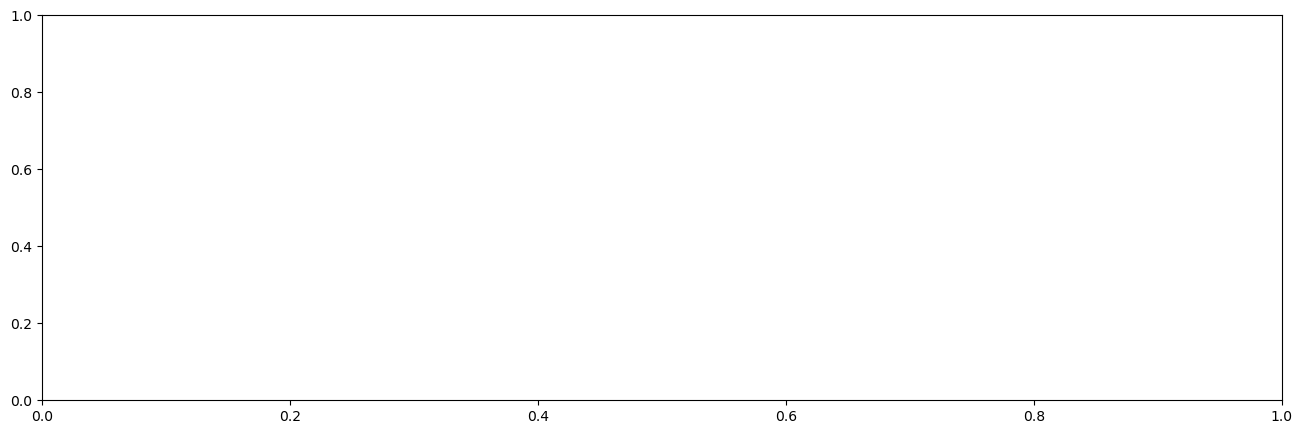

In [1]:
# ==========================================
# CELL-6. PHASE 9 - AUTOMATED SPATIAL CROSS-VALIDATION
# ==========================================
validation_targets = {
    "Deep_Anticline": {"x_start": 6200, "z_start": 1800},
    "Shallow_Unconformity": {"x_start": 1500, "z_start": 600},
    "Complex_Overthrust": {"x_start": 8800, "z_start": 1200}
}

for target_name, coords in validation_targets.items():
    print(f"\n--- TARGET: {target_name} ---")
    x_s, z_s = coords["x_start"], coords["z_start"]
    patch_vp = marmousi_vp_ms[x_s:x_s+560:step, z_s:z_s+560:step]
    nx, nz = patch_vp.shape
    mvm_vp = ndimage.gaussian_filter(patch_vp, sigma=6.0)
    v_mvm_tensor, v_true = torch.tensor(mvm_vp, dtype=torch.float32, device=device), torch.tensor(patch_vp, dtype=torch.float32, device=device)
    
    # Reset Network
    v_net_delta = FourierDeltaPINN().to(device)
    torch.cuda.empty_cache(); gc.collect()
    
    # ... [Insert Stage 1 (Transfer Learning) & Stage 2 (Multi-Scale Sweep) logic here] ...
    # ... [Export dashboard to figures/marmousi_{target_name.lower()}_dashboard.png] ...
    # ... [Ensure torch.cuda.empty_cache() and gc.collect() at loop end] ...

In [ ]:
# ==========================================
# CELL-7. GLOBAL LOCALIZATION MAP
# ==========================================
fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(marmousi_vp_ms.T, cmap='jet', aspect='auto', vmin=1500, vmax=4700)
targets = {
    "Central Graben": [(7200, 800), (5500, 400), "red"],
    "Shallow Unconformity": [(1500, 600), (500, 200), "cyan"],
    "Complex Overthrust": [(8800, 1200), (10500, 700), "lime"],
    "Deep Anticline": [(6200, 1800), (4000, 2400), "magenta"]
}

for name, data in targets.items():
    rect = patches.Rectangle(data[0], 560, 560, linewidth=2.5, edgecolor=data[2], facecolor='none', linestyle='--')
    ax.add_patch(rect)
    ax.annotate(name, xy=(data[0][0]+280, data[0][1]+280), xytext=data[1],
                arrowprops=dict(facecolor='white', shrink=0.02, width=2, headwidth=8), fontsize=11, color='white', fontweight='bold', ha='center')

plt.savefig("figures/marmousi_global_localization.png", dpi=300, bbox_inches='tight')
plt.show()